In [3]:
# Import packages
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the CSV dataset separated by semicolons
df = pd.read_csv('data4.csv', sep=';')

# Display the first 5 rows of the DataFrame
df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
0,S,S,P,F,S,Q,K,G,D,E,R,Y,K,Y,V,D,P,_
1,L,L,Q,Y,Y,G,M,T,E,M,N,Y,Y,T,V,L,F,_
2,L,L,N,P,K,K,Y,I,P,G,T,K,M,V,F,P,G,_
3,L,L,N,A,K,G,E,T,F,E,V,A,L,S,N,K,G,e
4,T,V,S,F,E,A,T,F,A,F,L,I,K,S,P,D,S,e


In [30]:
# Filter by amino acids present in the dataset
feature_cols = df.columns[:-1].tolist()   # V1 ... V17
target_col   = 'V18'

# Get the set of unique amino acids across columns V1 to V17
all_aa = set()
for col in feature_cols:
    all_aa.update(df[col].unique())
amino_acids = sorted(all_aa)

# Print the number of unique amino acids and the amino acid list
print(f'Number of unique amino acids: {len(amino_acids)}')
print(f'Amino acids: {amino_acids}')
print(f'\nPositions: {len(feature_cols)}')
print(f'Dimension after one-hot encoding: {len(feature_cols)} x {len(amino_acids)} = {len(feature_cols)*len(amino_acids)} features')

Number of unique amino acids: 20
Amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

Positions: 17
Dimension after one-hot encoding: 17 x 20 = 340 features


In [31]:
# Class distribution in the dataset
class_counts = df[target_col].value_counts() # Absolute frequency of each class
class_props  = df[target_col].value_counts(normalize=True).round(4) # Relative frequency of each class (proportion)

# Create a DataFrame to display the class distribution
dist_df = pd.DataFrame({
    'Class': ['α-Helix (h)', 'β-Sheet (e)', 'Coil (_)'],
    'Label': ['h', 'e', '_'],
    'Absolute frequency': [class_counts['h'], class_counts['e'], class_counts['_']],
    'Relative frequency': [class_props['h'], class_props['e'], class_props['_']]
})
dist_df['Relative frequency'] = dist_df['Relative frequency'].map('{:.2%}'.format) # Format relative frequency as percentage
print('Table 1. Distribution of classes in the dataset')
display(dist_df) # Display the table with the class distribution

Table 1. Distribution of classes in the dataset


,Class,Label,Absolute frequency,Relative frequency
0,α-Helix (h),h,2508,25.08%
1,β-Sheet (e),e,1935,19.35%
2,Coil (_),_,5557,55.57%


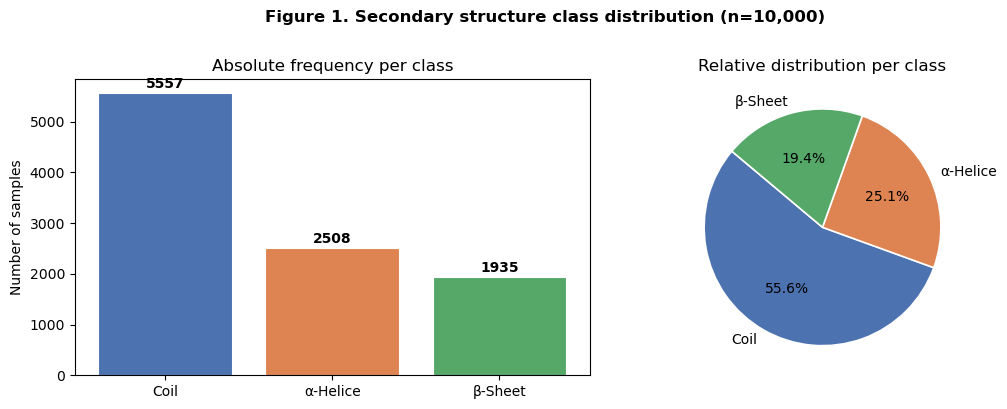

In [ ]:
# Plot the class distribution using a bar chart and a pie chart
# Figure 1: Secondary structure class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4)) 

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Coil', 'α-Helix', 'β-Sheet']
counts = [class_counts['_'], class_counts['h'], class_counts['e']]

# Barplot
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Absolute frequency per class')
for bar, count in zip(bars, counts): # Add labels with the sample count above each bar
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
axes[1].set_title('Relative distribution per class')

fig.suptitle('Figure 1. Secondary structure class distribution (n=10,000)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_distribucion_clases.png', bbox_inches='tight')
plt.show()

In [32]:
# One-hot encode the 17 amino acid columns
# Each position generates 20 binary columns (one per amino acid)
X = pd.get_dummies(df[feature_cols], prefix=feature_cols) # X will have 17 x 20 = 340 columns after one-hot encoding
y = df[target_col] # y will have 1 column with class labels (h, e, _)
 
print(f'Dimensions of X (features): {X.shape}')
print(f'Dimensions of y (labels): {y.shape}')
print(f'\nExample columns generated by one-hot encoding:')
print(X.columns[:10].tolist()) # Display the first 10 columns generated by one-hot encoding
print(f'\nUnique values in y: {sorted(y.unique())}')

Dimensions of X (features): (10000, 340)
Dimensions of y (labels): (10000,)

Example columns generated by one-hot encoding:
['V1_A', 'V1_C', 'V1_D', 'V1_E', 'V1_F', 'V1_G', 'V1_H', 'V1_I', 'V1_K', 'V1_L']

Unique values in y: ['_', 'e', 'h']


In [33]:
# Split 80% for training and 20% for testing
# stratify=y ensures class proportions are preserved in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training size: {len(X_train)} samples ({len(X_train)/len(X):.0%})')
print(f'Test size:     {len(X_test)} samples ({len(X_test)/len(X):.0%})')
print()
print('Class distribution in training set:')
print(y_train.value_counts(normalize=True).round(3)) # Proportion of each class in the training set
print('\nClass distribution in test set:')
print(y_test.value_counts(normalize=True).round(3)) # Proportion of each class in the test set

Training size: 8000 samples (80%)
Test size:     2000 samples (20%)

Class distribution in training set:
V18
_    0.556
h    0.251
e    0.194
Name: proportion, dtype: float64

Class distribution in test set:
V18
_    0.556
h    0.251
e    0.194
Name: proportion, dtype: float64


In [34]:
# Values of k to evaluate
# Odd values are used to avoid ties in voting
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

results = []

# Evaluate KNN model performance for each value of k
for k in k_values:
    # Euclidean distance (L2) as similarity measure
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1) # n_jobs=-1 used to speed up computation
    knn.fit(X_train, y_train) # Train the KNN model on the training set
    y_pred = knn.predict(X_test) # Class predictions for the test set
    
    acc   = accuracy_score(y_test, y_pred) # Accuracy: proportion of correct predictions over total samples
    err   = 1 - acc # Error: proportion of incorrect predictions over total samples
    kappa = cohen_kappa_score(y_test, y_pred) # Cohen's Kappa: agreement measure between predictions and true labels, adjusted for chance agreement
    
    # Store results in a list of dictionaries to later build a summary DataFrame
    results.append({'k': k, 'Accuracy': round(acc,4),
                    'Error': round(err,4), 'Kappa': round(kappa,4)})
    print(f'k={k:2d} | Accuracy={acc:.4f} | Error={err:.4f} | Kappa={kappa:.4f}')

results_df = pd.DataFrame(results)
print()
print('Table 2. Performance summary by k value')
display(results_df)

k= 1 | Accuracy=0.7700 | Error=0.2300 | Kappa=0.6118
k= 3 | Accuracy=0.7270 | Error=0.2730 | Kappa=0.5221
k= 5 | Accuracy=0.6965 | Error=0.3035 | Kappa=0.4582
k= 7 | Accuracy=0.6800 | Error=0.3200 | Kappa=0.4235
k= 9 | Accuracy=0.6640 | Error=0.3360 | Kappa=0.3822
k=11 | Accuracy=0.6395 | Error=0.3605 | Kappa=0.3284
k=15 | Accuracy=0.6360 | Error=0.3640 | Kappa=0.3071
k=21 | Accuracy=0.6190 | Error=0.3810 | Kappa=0.2559

Table 2. Performance summary by k value


,k,Accuracy,Error,Kappa
0,1,0.7700,0.2300,0.6118
1,3,0.7270,0.2730,0.5221
2,5,0.6965,0.3035,0.4582
3,7,0.6800,0.3200,0.4235
4,9,0.6640,0.3360,0.3822
5,11,0.6395,0.3605,0.3284
6,15,0.6360,0.3640,0.3071
7,21,0.6190,0.3810,0.2559


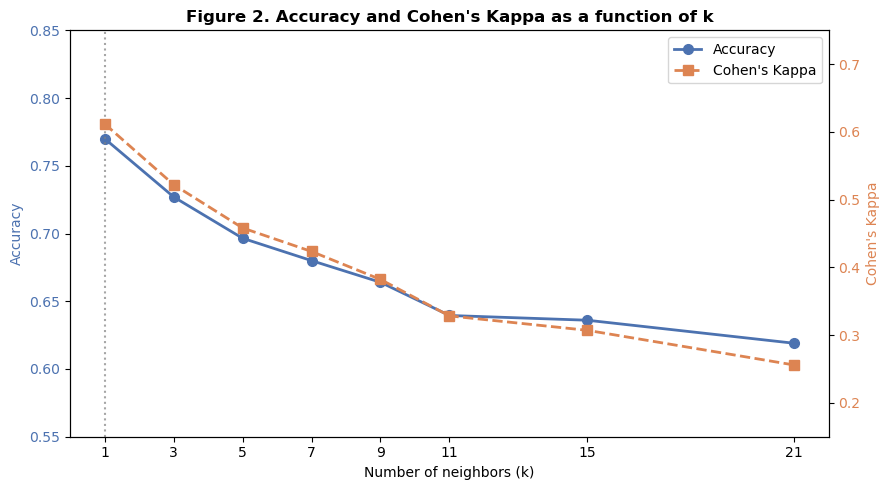

In [35]:
# Figure 2: Accuracy and Kappa as a function of k
fig, ax1 = plt.subplots(figsize=(9, 5))

# Define custom colors for the Accuracy and Kappa lines
color_acc   = '#4C72B0'
color_kappa = '#DD8452'

# Plot Accuracy on the left axis (ax1) and Kappa on the right axis (ax2)
ax1.plot(results_df['k'], results_df['Accuracy'], 'o-', color=color_acc,
         linewidth=2, markersize=7, label='Accuracy')
ax1.set_xlabel('Number of neighbors (k)')
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_xticks(results_df['k'])
ax1.set_ylim(0.55, 0.85)

# Create a second y-axis (ax2) to plot Cohen's Kappa
ax2 = ax1.twinx()
ax2.plot(results_df['k'], results_df['Kappa'], 's--', color=color_kappa,
         linewidth=2, markersize=7, label="Cohen's Kappa")
ax2.set_ylabel("Cohen's Kappa", color=color_kappa)
ax2.tick_params(axis='y', labelcolor=color_kappa)
ax2.set_ylim(0.15, 0.75)

# Mark the best k
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'k']
best_acc = results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']
ax1.axvline(x=best_k, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Figure 2. Accuracy and Cohen's Kappa as a function of k", fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_exactitud_kappa_k.png', bbox_inches='tight')
plt.show()

In [38]:
# Train the optimal model
best_k = int(results_df.loc[results_df['Accuracy'].idxmax(), 'k'])
print(f'Best k found: {best_k}')

# Train the KNN model with the best k found and evaluate its final performance on the test set
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_best.fit(X_train, y_train)

# Evaluate the performance of the optimal model on the test set
y_pred = knn_best.predict(X_test) # Class predictions for the test set
y_proba = knn_best.predict_proba(X_test) # Class probabilities for the test set (needed for AUC-ROC metrics)
classes = knn_best.classes_ # Classes in the order returned by predict_proba (h, e, _)

print(f'\nOverall accuracy: {accuracy_score(y_test, y_pred):.4f}') # Accuracy: proportion of correct predictions over total samples
print(f"Cohen's Kappa:    {cohen_kappa_score(y_test, y_pred):.4f}")
print(f'Classification error: {1-accuracy_score(y_test, y_pred):.4f}')

Best k found: 1

Overall accuracy: 0.7700
Cohen's Kappa:    0.6118
Classification error: 0.2300


In [39]:
# Full classification report
print('Table 3. Classification report (k=1)')
print(classification_report(
    y_test, y_pred,
    target_names=['α-Helix (h)', 'β-Sheet (e)', 'Coil (_)'],
    labels=['h', 'e', '_']
))

Table 3. Classification report (k=1)
              precision    recall  f1-score   support

 α-Helix (h)       0.72      0.75      0.74       502
 β-Sheet (e)       0.68      0.66      0.67       387
    Coil (_)       0.83      0.82      0.82      1111

    accuracy                           0.77      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.77      0.77      0.77      2000



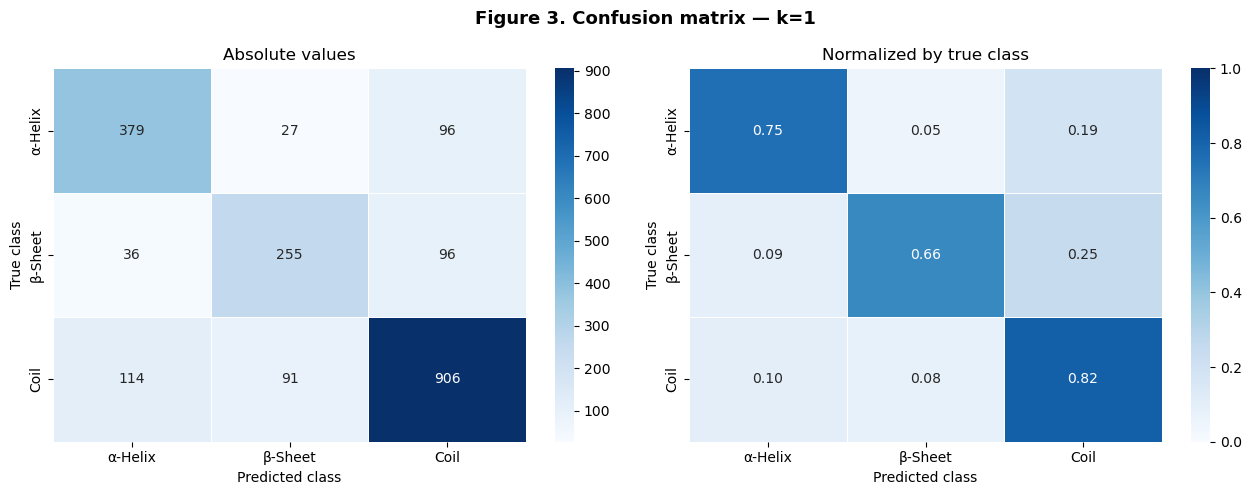


Error analysis per class:
  Clase h: TP=379, FP=150, FN=123
  Clase e: TP=255, FP=118, FN=132
  Clase _: TP=906, FP=192, FN=205


In [41]:
# Figure 3: Normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['h', 'e', '_'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

class_labels = ['α-Helix', 'β-Sheet', 'Coil']

# Absolute matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Absolute values')
axes[0].set_ylabel('True class')
axes[0].set_xlabel('Predicted class')

# Normalized matrix
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalized by true class')
axes[1].set_ylabel('True class')
axes[1].set_xlabel('Predicted class')

fig.suptitle(f'Figure 3. Confusion matrix — k={best_k}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_confusion_matrix.png', bbox_inches='tight')
plt.show()

# False positives and negatives per class
print('\nError analysis per class:')
for i, cls in enumerate(['h', 'e', '_']):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp   # false negatives (predicts another class)
    fp = cm[:, i].sum() - tp   # false positives (predicts this class when it is not)
    print(f'  Clase {cls}: TP={tp}, FP={fp}, FN={fn}')

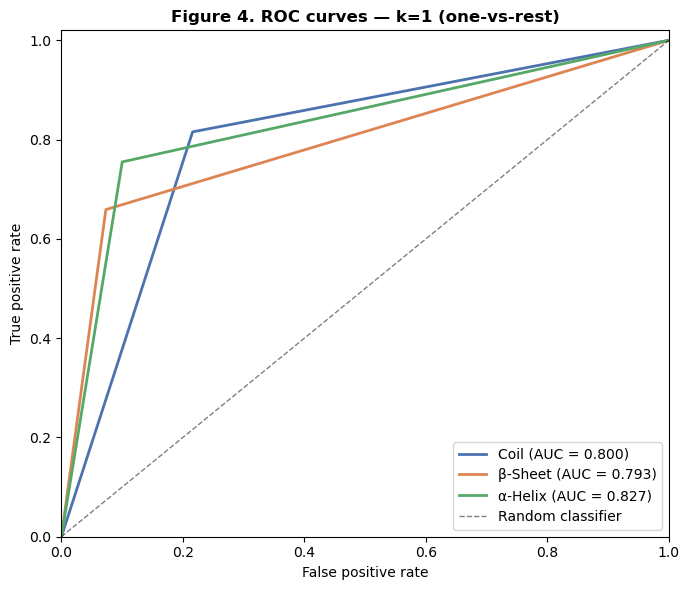


Macro-averaged AUC: 0.8067


In [42]:
# Figure 4: ROC curves (one-vs-rest)
y_bin = label_binarize(y_test, classes=classes)
class_name_map = {'_': 'Coil', 'e': 'β-Sheet', 'h': 'α-Helix'}
colors_roc = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(7, 6))

# Plot the ROC curve for each class in a one-vs-rest scheme
for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{class_name_map[cls]} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title(f'Figure 4. ROC curves — k={best_k} (one-vs-rest)', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', bbox_inches='tight')
plt.show()

# Macro-averaged AUC
auc_macro = roc_auc_score(y_bin, y_proba, average='macro')
print(f'\nMacro-averaged AUC: {auc_macro:.4f}')

In [43]:
# Summary table of all metrics for the best model
from sklearn.metrics import precision_score, recall_score, f1_score

print(f'  FINAL SUMMARY — Best model: k={best_k}')
print(f'  Overall accuracy   : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Classification error: {1-accuracy_score(y_test, y_pred):.4f}')
print(f"  Cohen's Kappa      : {cohen_kappa_score(y_test, y_pred):.4f}")
print(f'  Macro-averaged AUC : {auc_macro:.4f}')
print()
for cls, name in [('h','α-Helix'), ('e','β-Sheet'), ('_','Coil')]:
    mask = y_test == cls
    idx = list(classes).index(cls)
    auc_cls = roc_auc_score((y_test == cls).astype(int), y_proba[:, idx])
    print(f'  {name}: Prec={precision_score(y_test==cls, y_pred==cls):.3f}  '
          f'Recall={recall_score(y_test==cls, y_pred==cls):.3f}  '
          f'F1={f1_score(y_test==cls, y_pred==cls):.3f}  '
          f'AUC={auc_cls:.3f}')

  FINAL SUMMARY — Best model: k=1
  Overall accuracy   : 0.7700
  Classification error: 0.2300
  Cohen's Kappa      : 0.6118
  Macro-averaged AUC : 0.8067

  α-Helix: Prec=0.716  Recall=0.755  F1=0.735  AUC=0.827
  β-Sheet: Prec=0.684  Recall=0.659  F1=0.671  AUC=0.793
  Coil: Prec=0.825  Recall=0.815  F1=0.820  AUC=0.800
